# 🎭 Face Mask Detection — 3 Class Classification
**Dataset:** `vijaykumar1799/face-mask-detection`
**Classes:** `with_mask` | `without_mask` | `mask_weared_incorrect`
**Runtime:** Google Colab + GPU (T4)

## 📦 1. Install & Import Library

In [ ]:
!pip install -q tensorflow scikit-learn matplotlib seaborn numpy pillow

import tensorflow as tf
print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU:', gpus if gpus else '❌ Tidak ada GPU — aktifkan di Runtime > Change runtime type > T4 GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    GlobalAveragePooling2D, BatchNormalization, Input
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('✅ Library siap')

✅ Library siap


## 📥 2. Download Dataset dari Kaggle

In [ ]:
from google.colab import files
print('Upload kaggle.json (Kaggle > Account > API > Create New Token):')
files.upload()

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d vijaykumar1799/face-mask-detection
!unzip -q face-mask-detection.zip -d dataset

In [ ]:
print('\n📁 Struktur dataset:')
for cls in sorted(os.listdir('dataset/Dataset')):
    cls_path = os.path.join('dataset/Dataset', cls)
    if os.path.isdir(cls_path):
        n = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f'  {cls:35s}: {n} gambar')


📁 Struktur dataset:
  mask_weared_incorrect              : 2994 gambar
  with_mask                          : 2994 gambar
  without_mask                       : 2994 gambar


## ⚙️ 3. Konfigurasi & Data Generator

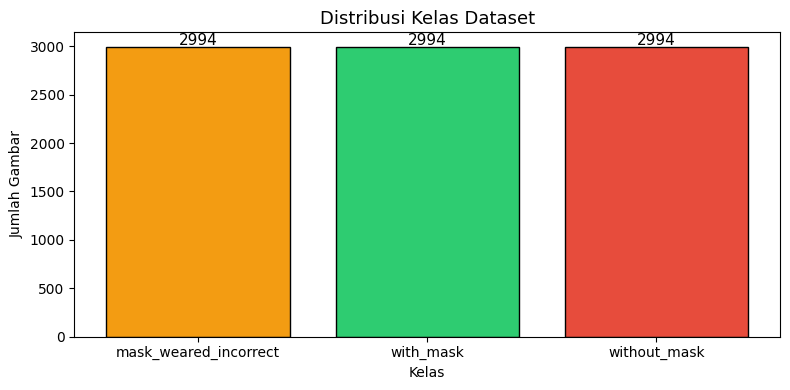


⚠️ Dataset IMBALANCED — class_weight akan dipakai


In [ ]:
DATASET_PATH = 'dataset/Dataset'
IMG_SIZE_CNN = 128
IMG_SIZE_TL  = 224
BATCH_SIZE   = 32
NUM_CLASSES  = 3

class_counts = {}
for cls in sorted(os.listdir(DATASET_PATH)):
    p = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(p):
        class_counts[cls] = len([f for f in os.listdir(p) if f.lower().endswith(('.jpg','.jpeg','.png'))])

plt.figure(figsize=(8, 4))
bars = plt.bar(class_counts.keys(), class_counts.values(),
               color=['#f39c12','#2ecc71','#e74c3c'], edgecolor='black')
plt.title('Distribusi Kelas Dataset', fontsize=13)
plt.xlabel('Kelas'); plt.ylabel('Jumlah Gambar')
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+20,
             str(int(b.get_height())), ha='center', fontsize=11)
plt.tight_layout(); plt.show()

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.20)

def make_generators(img_size):
    train = train_datagen.flow_from_directory(
        DATASET_PATH, target_size=(img_size,img_size),
        batch_size=BATCH_SIZE, class_mode='categorical',
        subset='training', seed=SEED, shuffle=True
    )
    val = val_datagen.flow_from_directory(
        DATASET_PATH, target_size=(img_size,img_size),
        batch_size=BATCH_SIZE, class_mode='categorical',
        subset='validation', seed=SEED,
        shuffle=False
    )
    return train, val

train_gen_cnn, val_gen_cnn = make_generators(IMG_SIZE_CNN)
train_gen_tl,  val_gen_tl  = make_generators(IMG_SIZE_TL)
print('Class indices:', train_gen_cnn.class_indices)
print(f'Train: {train_gen_cnn.n} | Val: {val_gen_cnn.n}')

Found 7188 images belonging to 3 classes.
Found 1794 images belonging to 3 classes.
Found 7188 images belonging to 3 classes.
Found 1794 images belonging to 3 classes.
Class indices: {'mask_weared_incorrect': 0, 'with_mask': 1, 'without_mask': 2}
Train: 7188 | Val: 1794


In [ ]:
y_train = train_gen_cnn.classes
cw_arr  = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(cw_arr))
print('Class weights:')
for i,(k,w) in enumerate(zip(train_gen_cnn.class_indices.keys(), cw_arr)):
    print(f'  [{i}] {k:35s}: {w:.4f}')

Class weights:
  [0] mask_weared_incorrect              : 1.0000
  [1] with_mask                          : 1.0000
  [2] without_mask                       : 1.0000


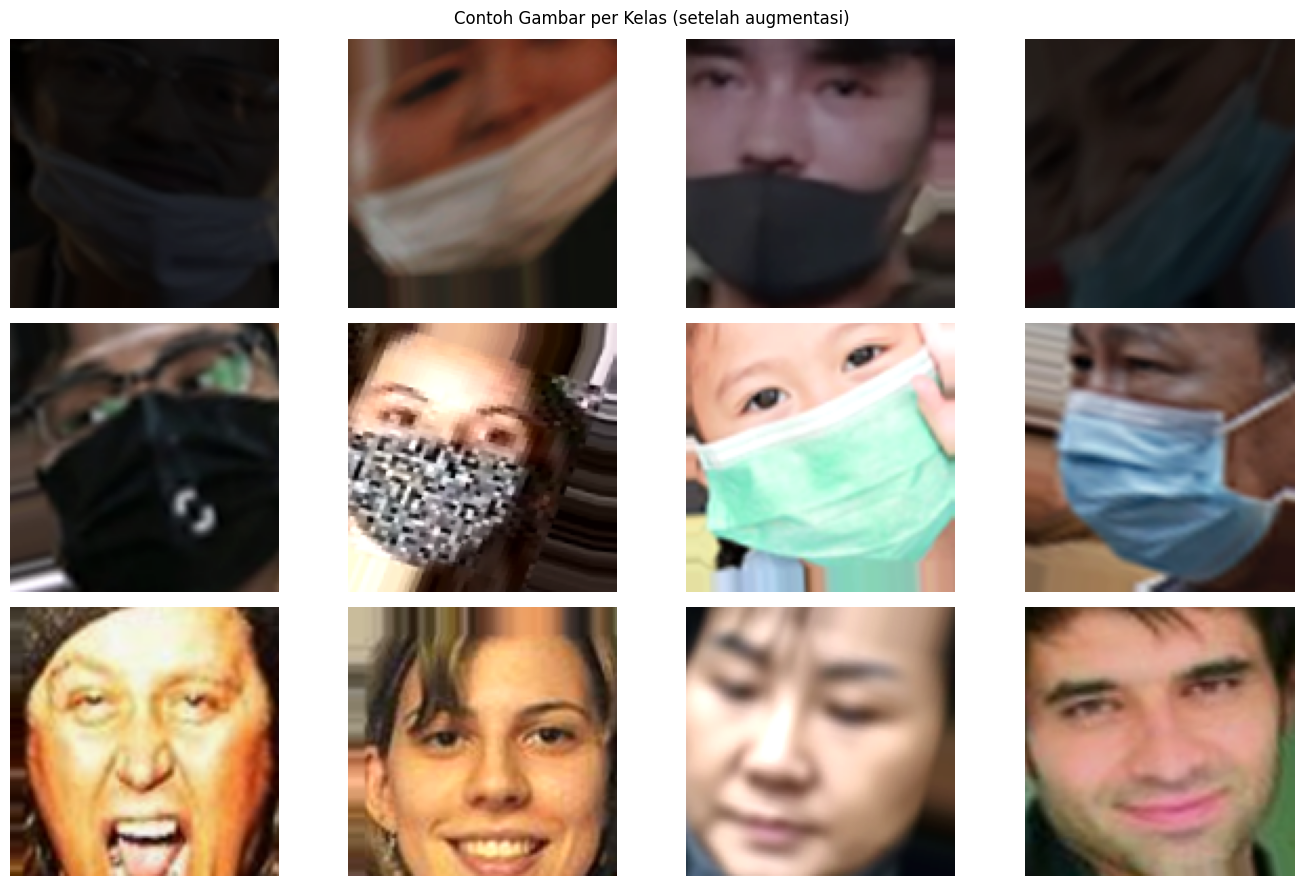

In [ ]:
CLASS_LABELS = {v:k for k,v in train_gen_cnn.class_indices.items()}
batch_imgs, batch_labels = next(train_gen_cnn)

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for row, target in enumerate(range(3)):
    count = 0
    for i in range(len(batch_imgs)):
        if np.argmax(batch_labels[i]) == target and count < 4:
            axes[row][count].imshow(batch_imgs[i])
            axes[row][count].axis('off')
            if count == 0:
                axes[row][count].set_ylabel(CLASS_LABELS[target],
                                            fontsize=9, fontweight='bold', rotation=0,
                                            labelpad=60, va='center')
            count += 1
        if count == 4: break
plt.suptitle('Contoh Gambar per Kelas (setelah augmentasi)', fontsize=12)
plt.tight_layout(); plt.show()

## 🛠️ 4. Helper Functions — Evaluasi & Visualisasi

In [ ]:
def plot_history(history, title='Model'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
    axes[0].plot(history.history['val_accuracy'], label='Val',   color='coral', linestyle='--')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].axhline(0.9, color='green', linestyle=':', label='Target 90%')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
    axes[1].plot(history.history['val_loss'], label='Val',   color='coral', linestyle='--')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    print(f'  Best Val Acc : {max(history.history["val_accuracy"]):.4f}')
    print(f'  Best Val Loss: {min(history.history["val_loss"]):.4f}')


def evaluate_model(model, generator, model_name='Model'):
    generator.reset()
    y_true  = generator.classes
    y_prob  = model.predict(generator, verbose=1)
    y_pred  = np.argmax(y_prob, axis=1)
    labels  = list(generator.class_indices.keys())
    acc = accuracy_score(y_true, y_pred)
    cm  = confusion_matrix(y_true, y_pred)

    print(f'\n{"="*55}')
    print(f'📊 Evaluasi: {model_name}')
    print(f'{"="*55}')
    status = '✅' if acc >= 0.9 else '❌ belum mencapai target 90%'
    print(f'Accuracy : {acc:.4f}  {status}')

    # Confusion Matrix
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, linewidths=0.5)
    plt.title(f'Confusion Matrix — {model_name}', fontsize=12)
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.xticks(rotation=20, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()

    # Classification Report
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=labels, digits=4))

    return {'acc': acc, 'y_true': y_true, 'y_pred': y_pred, 'y_prob': y_prob}


def plot_comparison(results_dict):
    names  = list(results_dict.keys())
    accs   = [r['acc'] for r in results_dict.values()]
    colors = ['steelblue', 'coral', 'mediumseagreen']
    plt.figure(figsize=(8, 5))
    bars = plt.bar(names, accs, color=colors[:len(names)], edgecolor='black', width=0.5)
    plt.axhline(0.9, color='green', linestyle='--', linewidth=1.5, label='Target 90%')
    plt.ylim(0, 1.1); plt.title('Perbandingan Validation Accuracy', fontsize=13)
    plt.ylabel('Accuracy'); plt.legend()
    for b, a in zip(bars, accs):
        plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.015,
                 f'{a:.4f}', ha='center', fontsize=11)
    plt.tight_layout(); plt.show()


print('✅ Helper functions siap')

✅ Helper functions siap


## 🧠 5. CNN Custom (Improved)

In [ ]:
def build_cnn(img_size=128, num_classes=3):
    return Sequential([
        # Block 1
        Conv2D(32,(3,3), activation='relu', padding='same', input_shape=(img_size,img_size,3)),
        BatchNormalization(), MaxPooling2D(2,2),
        # Block 2
        Conv2D(64,(3,3), activation='relu', padding='same'),
        BatchNormalization(), MaxPooling2D(2,2),
        # Block 3
        Conv2D(128,(3,3), activation='relu', padding='same'),
        BatchNormalization(), MaxPooling2D(2,2),
        # Block 4
        Conv2D(256,(3,3), activation='relu', padding='same'),
        BatchNormalization(), MaxPooling2D(2,2),
        Flatten(),
        Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(), Dropout(0.5),
        Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ], name='CNN_Custom')

cnn_model = build_cnn(IMG_SIZE_CNN, NUM_CLASSES)
cnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Custom"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,619,203 (17.62 MB)

 Trainable params: 4,617,731 (17.62 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
cnn_callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint('/content/best_cnn.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

print('=== Training CNN Custom ===')
cnn_history = cnn_model.fit(
    train_gen_cnn,
    validation_data=val_gen_cnn,
    epochs=50,
    callbacks=cnn_callbacks,
    class_weight=class_weight_dict
)

=== Training CNN Custom ===
Epoch 1/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.7785 - loss: 0.7239
Epoch 1: val_accuracy improved from None to 0.45652, saving model to /content/best_cnn.keras

Epoch 1: finished saving model to /content/best_cnn.keras
225/225 ━━━━━━━━━━━━━━━━━━━━ 68s 247ms/step - accuracy: 0.8236 - loss: 0.5830 - val_accuracy: 0.4565 - val_loss: 1.5100 - learning_rate: 0.0010
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.8908 - loss: 0.4087
Epoch 2: val_accuracy improved from 0.45652 to 0.82497, saving model to /content/best_cnn.keras

Epoch 2: finished saving model to /content/best_cnn.keras
225/225 ━━━━━━━━━━━━━━━━━━━━ 46s 206ms/step - accuracy: 0.9016 - loss: 0.3882 - val_accuracy: 0.8250 - val_loss: 0.6231 - learning_rate: 0.0010
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.9108 - loss: 0.3579
Epoch 3: val_accuracy improved from 0.82497 to 0.95931, saving model to /content/best_cnn.keras

Epoch 3: finishe

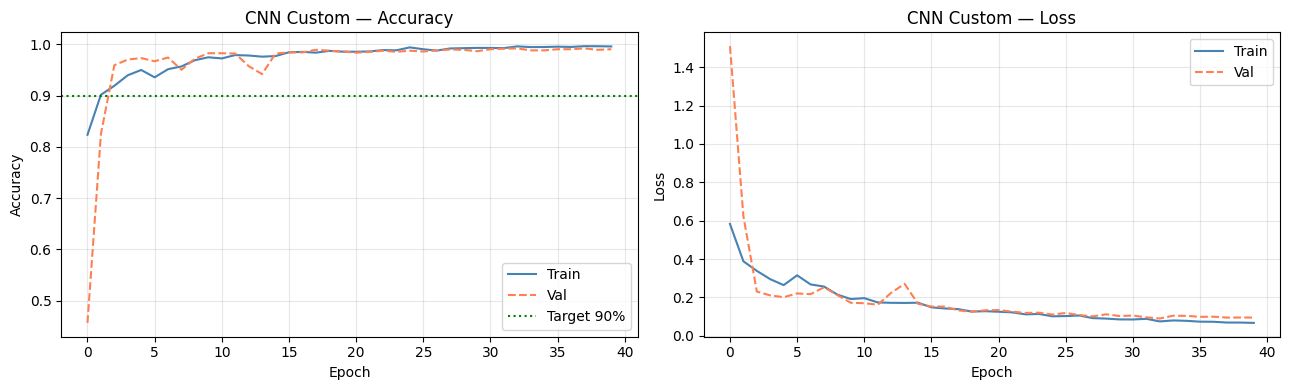

  Best Val Acc : 0.9922
  Best Val Loss: 0.0899


In [ ]:
plot_history(cnn_history, title='CNN Custom')

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step

📊 Evaluasi: CNN Custom
Accuracy : 0.9922  ✅


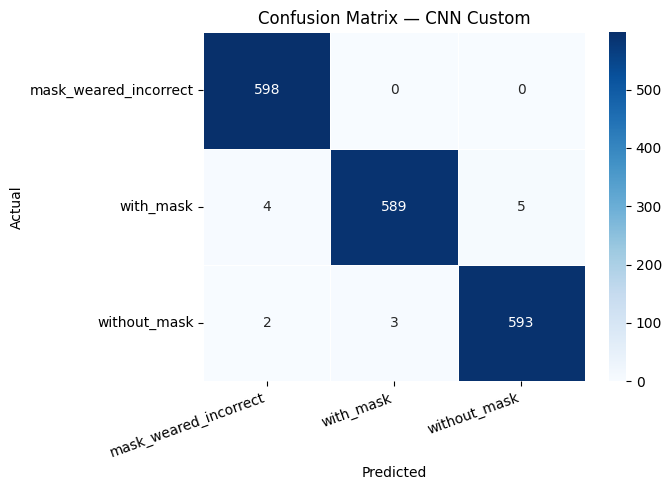


Classification Report:
                       precision    recall  f1-score   support

mask_weared_incorrect     0.9901    1.0000    0.9950       598
            with_mask     0.9949    0.9849    0.9899       598
         without_mask     0.9916    0.9916    0.9916       598

             accuracy                         0.9922      1794
            macro avg     0.9922    0.9922    0.9922      1794
         weighted avg     0.9922    0.9922    0.9922      1794



In [ ]:
cnn_results = evaluate_model(cnn_model, val_gen_cnn, model_name='CNN Custom')

## 🚀 6. Transfer Learning — MobileNetV2 (2 Fase)

In [ ]:
base_model = MobileNetV2(weights='imagenet', include_top=False,
                         input_shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3))
base_model.trainable = False

inputs  = Input(shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3))
x       = base_model(inputs, training=False)
x       = GlobalAveragePooling2D()(x)
x       = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x)
x       = BatchNormalization()(x)
x       = Dropout(0.5)(x)
x       = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
x       = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = Model(inputs, outputs, name='MobileNetV2_TL')
tl_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(f'Total params    : {tl_model.count_params():,}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total params    : 2,620,227


=== Transfer Learning — Fase 1 (Frozen Base) ===
Epoch 1/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.7995 - loss: 0.6749
Epoch 1: val_accuracy improved from None to 0.88852, saving model to /content/best_tl_p1.keras

Epoch 1: finished saving model to /content/best_tl_p1.keras
225/225 ━━━━━━━━━━━━━━━━━━━━ 151s 575ms/step - accuracy: 0.8721 - loss: 0.4270 - val_accuracy: 0.8885 - val_loss: 0.3742 - learning_rate: 0.0010
Epoch 2/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.9192 - loss: 0.2784
Epoch 2: val_accuracy improved from 0.88852 to 0.92698, saving model to /content/best_tl_p1.keras

Epoch 2: finished saving model to /content/best_tl_p1.keras
225/225 ━━━━━━━━━━━━━━━━━━━━ 98s 434ms/step - accuracy: 0.9257 - loss: 0.2675 - val_accuracy: 0.9270 - val_loss: 0.2338 - learning_rate: 0.0010
Epoch 3/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.9326 - loss: 0.2504
Epoch 3: val_accuracy improved from 0.92698 to 0.94649, saving model to /content/be

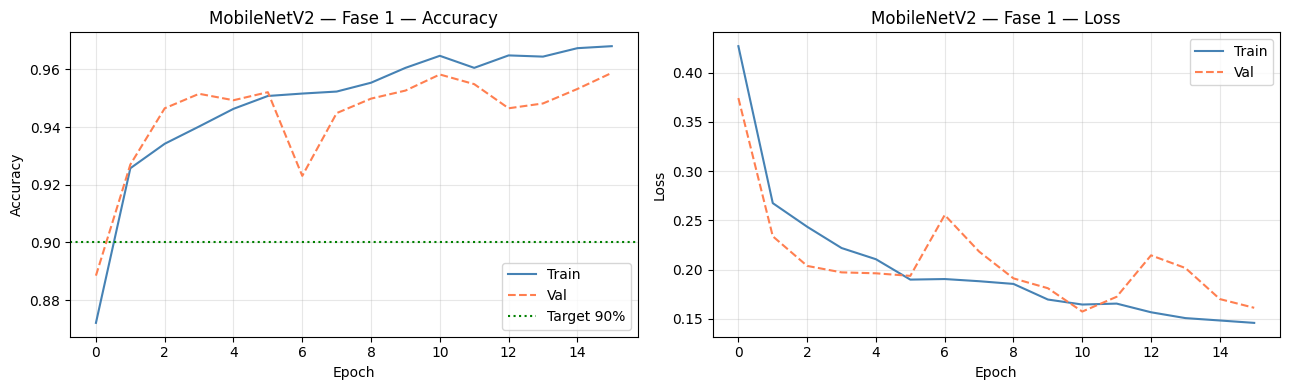

  Best Val Acc : 0.9588
  Best Val Loss: 0.1574


In [ ]:
# FASE 1: Frozen base — latih hanya top layers
cb_p1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('/content/best_tl_p1.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]
print('=== Transfer Learning — Fase 1 (Frozen Base) ===')
hist_p1 = tl_model.fit(
    train_gen_tl, validation_data=val_gen_tl,
    epochs=25, callbacks=cb_p1, class_weight=class_weight_dict
)
plot_history(hist_p1, title='MobileNetV2 — Fase 1')

Trainable params: 2,216,835

=== Transfer Learning — Fase 2 (Fine-tuning) ===
Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.8694 - loss: 0.4503
Epoch 1: val_accuracy improved from None to 0.90803, saving model to /content/best_tl_finetuned.keras

Epoch 1: finished saving model to /content/best_tl_finetuned.keras
225/225 ━━━━━━━━━━━━━━━━━━━━ 143s 534ms/step - accuracy: 0.8919 - loss: 0.3769 - val_accuracy: 0.9080 - val_loss: 0.3189 - learning_rate: 1.0000e-05
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.9340 - loss: 0.2602
Epoch 2: val_accuracy improved from 0.90803 to 0.90914, saving model to /content/best_tl_finetuned.keras

Epoch 2: finished saving model to /content/best_tl_finetuned.keras
225/225 ━━━━━━━━━━━━━━━━━━━━ 101s 449ms/step - accuracy: 0.9343 - loss: 0.2457 - val_accuracy: 0.9091 - val_loss: 0.3373 - learning_rate: 1.0000e-05
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.9431 - loss: 0.2219
Epoch 3: val_accu

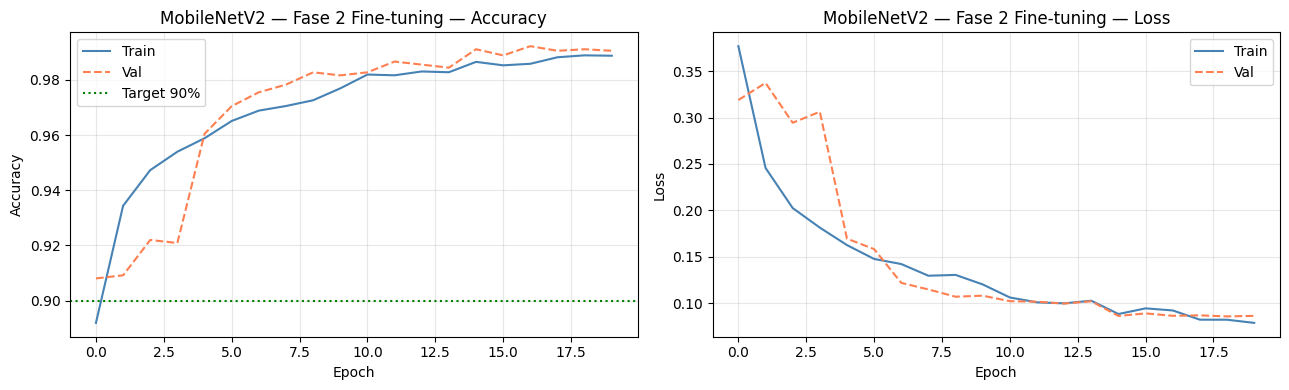

  Best Val Acc : 0.9922
  Best Val Loss: 0.0858


In [ ]:
# FASE 2: Fine-tuning — unfreeze 50 layer terakhir
base_model.trainable = True
for layer in base_model.layers[:len(base_model.layers)-50]:
    layer.trainable = False

tl_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(f'Trainable params: {sum(tf.keras.backend.count_params(w) for w in tl_model.trainable_weights):,}')

cb_p2 = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint('/content/best_tl_finetuned.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]
print('\n=== Transfer Learning — Fase 2 (Fine-tuning) ===')
hist_p2 = tl_model.fit(
    train_gen_tl, validation_data=val_gen_tl,
    epochs=20, callbacks=cb_p2, class_weight=class_weight_dict
)
plot_history(hist_p2, title='MobileNetV2 — Fase 2 Fine-tuning')

57/57 ━━━━━━━━━━━━━━━━━━━━ 12s 135ms/step

📊 Evaluasi: MobileNetV2 Fine-tuned
Accuracy : 0.9911  ✅


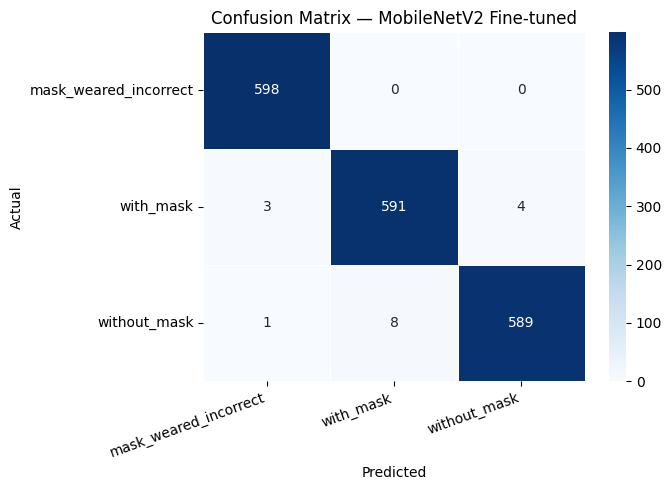


Classification Report:
                       precision    recall  f1-score   support

mask_weared_incorrect     0.9934    1.0000    0.9967       598
            with_mask     0.9866    0.9883    0.9875       598
         without_mask     0.9933    0.9849    0.9891       598

             accuracy                         0.9911      1794
            macro avg     0.9911    0.9911    0.9911      1794
         weighted avg     0.9911    0.9911    0.9911      1794



In [ ]:
tl_results = evaluate_model(tl_model, val_gen_tl, model_name='MobileNetV2 Fine-tuned')

## 📊 7. Perbandingan Semua Model

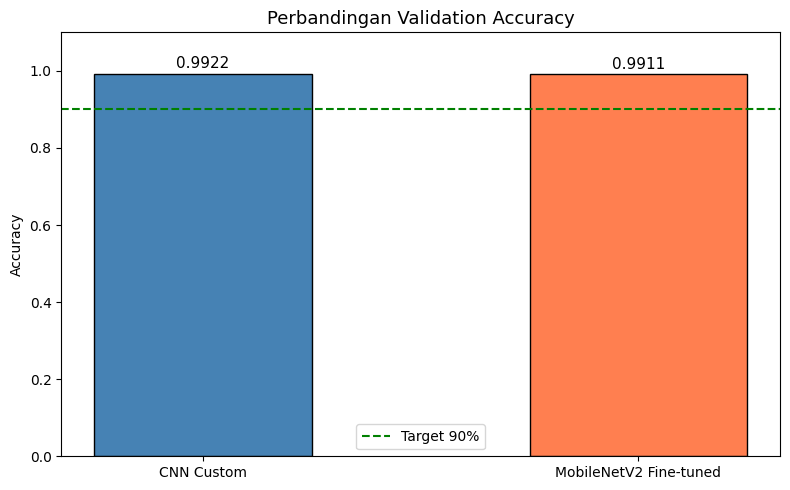


=== Ringkasan Akhir ===
Model                             Val Acc
------------------------------------------
CNN Custom                         0.9922  ✅
MobileNetV2 Fine-tuned             0.9911  ✅


In [ ]:
all_results = {
    'CNN Custom'            : cnn_results,
    'MobileNetV2 Fine-tuned': tl_results,
}
plot_comparison(all_results)

print('\n=== Ringkasan Akhir ===')
print(f'{"Model":<30} {"Val Acc":>10}')
print('-' * 42)
for name, res in all_results.items():
    status = '✅' if res['acc'] >= 0.9 else '❌'
    print(f'{name:<30} {res["acc"]:>10.4f}  {status}')

## 🔍 8. Inference — Prediksi Gambar Baru

In [ ]:
from tensorflow.keras.preprocessing import image as keras_image

BEST_MODEL    = tl_model
BEST_IMG_SIZE = IMG_SIZE_TL
CLS_LABELS    = {v:k for k,v in train_gen_tl.class_indices.items()}

def predict_image(img_path, model=BEST_MODEL, img_size=BEST_IMG_SIZE):
    img = keras_image.load_img(img_path, target_size=(img_size, img_size))
    arr = keras_image.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)
    probs     = model.predict(arr, verbose=0)[0]
    pred_idx  = np.argmax(probs)
    pred_label= CLS_LABELS[pred_idx]
    confidence= probs[pred_idx]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(np.array(img)); axes[0].axis('off')
    color = '#2ecc71' if pred_label=='with_mask' else \
            '#e74c3c' if pred_label=='without_mask' else '#f39c12'
    axes[0].set_title(f'Prediksi: {pred_label}\nConfidence: {confidence:.2%}',
                      color=color, fontsize=12, fontweight='bold')

    bar_colors = ['#f39c12' if CLS_LABELS[i]=='mask_weared_incorrect'
                  else '#2ecc71' if CLS_LABELS[i]=='with_mask'
                  else '#e74c3c' for i in range(len(probs))]
    bars = axes[1].barh([CLS_LABELS[i] for i in range(len(probs))],
                        probs, color=bar_colors, edgecolor='black')
    axes[1].set_xlim(0, 1); axes[1].set_xlabel('Probability')
    axes[1].set_title('Probabilitas per Kelas')
    for b, p in zip(bars, probs):
        axes[1].text(b.get_width()+0.01, b.get_y()+b.get_height()/2,
                     f'{p:.2%}', va='center', fontsize=10)
    axes[1].grid(True, axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()
    return pred_label, confidence

print('✅ Fungsi predict_image siap!')
print('Cara pakai: predict_image("/path/ke/gambar.jpg")')

✅ Fungsi predict_image siap!
Cara pakai: predict_image("/path/ke/gambar.jpg")


Upload gambar untuk diuji (jpg/png):


Saving 5.jpg to 5 (1).jpg

--- Prediksi: 5 (1).jpg ---


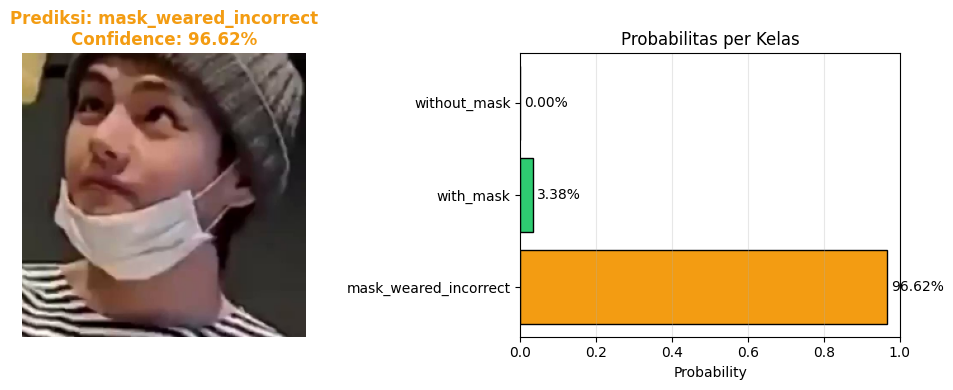

Hasil: mask_weared_incorrect (96.62%)


In [ ]:
from google.colab import files
print('Upload gambar untuk diuji (jpg/png):')
uploaded = files.upload()
for fname in uploaded.keys():
    print(f'\n--- Prediksi: {fname} ---')
    label, conf = predict_image(fname)
    print(f'Hasil: {label} ({conf:.2%})')

In [ ]:
tl_model.save('/content/mobilenetv2_facemask_final.keras')
cnn_model.save('/content/cnn_facemask_final.keras')
print('✅ Model tersimpan di /content/')

from google.colab import files
files.download('/content/mobilenetv2_facemask_final.keras')
files.download('/content/cnn_facemask_final.keras')

✅ Model tersimpan di /content/


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>